# Multimodal Phishing Detection: 9-Model Wide-Stacking Architecture

**Objective:** Implement a highly-accurate 9-model Late-Fusion architecture across three modalities (URL, Text, Visual).

###  STRICT FAIL-FAST PROTOCOL ENABLED
This pipeline is designed to **halt immediately** if data is missing. It requires visual proof of image loading before allowing heavy Deep Learning models to execute.

In [1]:
import os
import numpy as np
import pandas as pd
import math
import re
from urllib.parse import urlparse, unquote
import tldextract
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    matthews_corrcoef, precision_recall_curve, auc, confusion_matrix, roc_curve
)
from scipy.stats import spearmanr, pearsonr

# ML Models
from xgboost import XGBClassifier
import lightgbm as lgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier

# Deep Learning Extractors
from sentence_transformers import SentenceTransformer
from torchvision import models, transforms
from PIL import Image

import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\n Libraries imported successfully! Using device: {device}")


Libraries imported successfully! Using device: cpu


### Phase 1: Data Loading & Strict Balancing

In [2]:
# WINDOWS PATH CONFIGURATION
BASE_DIR = r'C:\Users\LENOVO\Downloads\FINAL_PROJECT_MLPR\phish360\Phish360'
PHISH_PATH = os.path.join(BASE_DIR, 'Phish360_phish.parquet')
LEGIT_PATH = os.path.join(BASE_DIR, 'Phish360_legit.parquet')

print("Loading Parquet files from local disk...")
if not os.path.exists(PHISH_PATH) or not os.path.exists(LEGIT_PATH):
    raise FileNotFoundError(f"CRITICAL ERROR: Could not find Parquet files at {BASE_DIR}. HALTING.")

phish_df = pd.read_parquet(PHISH_PATH)
legit_df = pd.read_parquet(LEGIT_PATH)
print(f" Datasets loaded. (Phish: {len(phish_df)}, Legit: {len(legit_df)})")

# Balancing
min_class_count = len(phish_df)
legit_df = legit_df.sample(n=min_class_count, random_state=42)
df = pd.concat([phish_df, legit_df]).sample(frac=1, random_state=42).reset_index(drop=True)
df['target'] = (df['Class'] == 'phish').astype(int)

print(f"Dataset perfectly balanced to {len(df)} rows.")

Loading Parquet files from local disk...
Datasets loaded. (Phish: 4332, Legit: 6416)
Dataset perfectly balanced to 8664 rows.


### CHECKPOINT: Strict Image Path Validation & Visual Proof 
This cell will explicitly check if the images exist on your hard drive. 
If it cannot find them, **it will crash intentionally** so you do not waste time training on zero-padded data.

Initiating Strict Image Path Validation...


Validating Paths:   0%|          | 0/8664 [00:00<?, ?it/s]


 Path Diagnostic: 8663 found, 1 missing.

PATH VALIDATION PASSED. Generating Visual Proof...


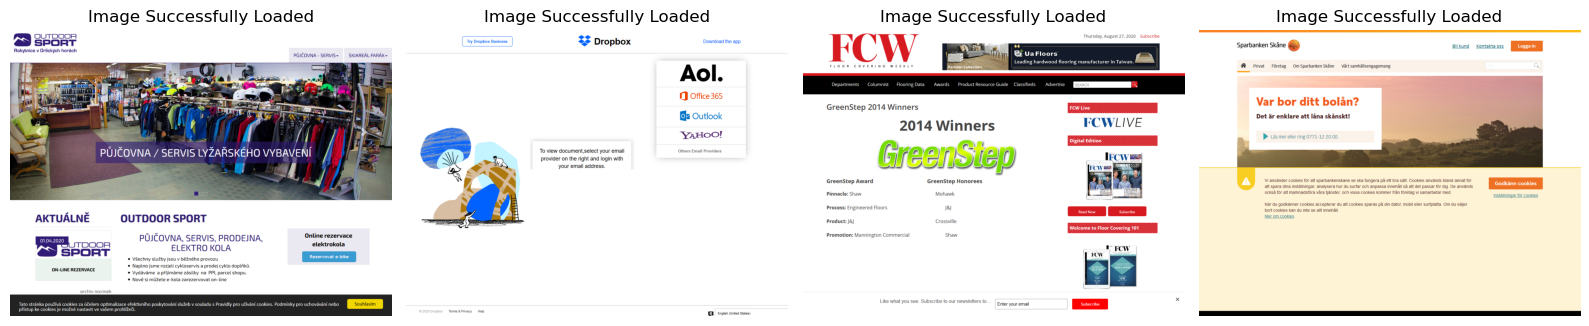

IF YOU DO NOT SEE 4 IMAGES ABOVE, STOP THE NOTEBOOK NOW. 


In [3]:
print("Initiating Strict Image Path Validation...")
missing_images = 0
valid_paths = []

for img_path in tqdm(df['image_path'], desc="Validating Paths"):
    clean_path = str(img_path).replace('/', '\\')
    full_path = os.path.join(BASE_DIR, clean_path)
    
    # Fallback check if 'Phish360' is duplicated in the directory tree
    if not os.path.exists(full_path) and "Phish360\\" in clean_path:
        full_path = os.path.join(BASE_DIR, clean_path.split("Phish360\\")[-1])
        
    if os.path.exists(full_path):
        valid_paths.append(full_path)
    else:
        missing_images += 1
        # Save the first missing path to show the user exactly what is failing
        if missing_images == 1:
            example_missing = full_path

# --- THE FAIL-FAST TRIGGER ---
missing_percentage = (missing_images / len(df)) * 100
print(f"\n🔍 Path Diagnostic: {len(valid_paths)} found, {missing_images} missing.")

if missing_percentage > 5.0: # If more than 5% are missing, violently halt.
    error_msg = f"\n🚨 CRITICAL HALT 🚨\n{missing_images} images are missing ({missing_percentage:.1f}%).\nI am halting the pipeline so you do not waste time training on zeros.\nExample of a path I tried to look for but couldn't find:\n-> {example_missing}"
    raise RuntimeError(error_msg)

print("\n✅ PATH VALIDATION PASSED. Generating Visual Proof...")

# --- VISUAL PROOF ---
# Plot 4 random images to prove data is actually accessible in RAM
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
sample_paths = np.random.choice(valid_paths, 4, replace=False)

for i, path in enumerate(sample_paths):
    img = Image.open(path)
    axes[i].imshow(img)
    axes[i].axis('off')
    axes[i].set_title("Image Successfully Loaded")
plt.tight_layout()
plt.show()
print("IF YOU DO NOT SEE 4 IMAGES ABOVE, STOP THE NOTEBOOK NOW.")

### Phase 2: Strict 54-Feature URL Extraction
Extracts deterministic features and saves the completed dataset to a Parquet file.

In [4]:
def calculate_entropy(text):
    if not text: return 0
    probs = [text.count(c) / len(text) for c in set(text)]
    return -sum(p * math.log(p, 2) for p in probs)

def extract_54_url_features_strict(url):
    url = str(url).strip()
    if not url or url.lower() == 'nan': return None
    
    extracted = tldextract.extract(url)
    parsed = urlparse(url)
    decoded_url = unquote(url)
    
    domain = extracted.domain
    subdomain = extracted.subdomain
    path = parsed.path
    query = parsed.query
    
    f = {}
    f['URLLength'] = len(url)
    f['DomainLength'] = len(domain)
    f['TLDLength'] = len(extracted.suffix)
    f['SubdomainLength'] = len(subdomain)
    f['PathLength'] = len(path)
    f['QueryLength'] = len(query)
    f['NoOfSubDomain'] = len(subdomain.split('.')) if subdomain else 0
    f['DirectoryLevels'] = path.count('/')
    f['IsHTTPS'] = 1 if parsed.scheme == 'https' else 0
    f['IsDomainIP'] = 1 if re.match(r"^\d{1,3}(\.\d{1,3}){3}$", domain) else 0
    f['HasObfuscation'] = 1 if decoded_url != url else 0
    f['IsShortened'] = 1 if len(domain) <= 7 and f['NoOfSubDomain'] == 0 else 0
    f['HasCreds'] = 1 if '@' in parsed.netloc else 0
    f['HasHiddenRedirect'] = 1 if 'http' in path or 'www' in path or 'http' in query else 0
    letters = sum(c.isalpha() for c in url)
    digits = sum(c.isdigit() for c in url)
    special_chars = len(re.sub(r'[a-zA-Z0-9]', '', url))
    f['LetterRatioInURL'] = letters / len(url) if len(url) > 0 else 0
    f['DigitRatioInURL'] = digits / len(url) if len(url) > 0 else 0
    f['SpecialCharRatioInURL'] = special_chars / len(url) if len(url) > 0 else 0
    f['DomainLetterRatio'] = sum(c.isalpha() for c in domain) / len(domain) if len(domain) > 0 else 0
    f['DomainDigitRatio'] = sum(c.isdigit() for c in domain) / len(domain) if len(domain) > 0 else 0
    f['ObfuscationRatio'] = (len(url) - len(decoded_url)) / len(url) if f['HasObfuscation'] and len(url) > 0 else 0
    longest_alphanum = max((len(s) for s in re.findall(r'[a-zA-Z0-9]+', url)), default=0)
    f['CharContinuationRate'] = longest_alphanum / len(url) if len(url) > 0 else 0
    f['NoOfLettersInURL'] = letters
    f['NoOfDigitsInURL'] = digits
    f['NoOfEqualsInURL'] = url.count('=')
    f['NoOfQMarkInURL'] = url.count('?')
    f['NoOfAmpersandInURL'] = url.count('&')
    f['NoOfHyphensInURL'] = url.count('-')
    f['NoOfAtInURL'] = url.count('@')
    f['NoOfTildeInURL'] = url.count('~')
    f['NoOfUnderscoreInURL'] = url.count('_')
    f['NoOfPercentInURL'] = url.count('%')
    f['NoOfSlashInURL'] = url.count('/')
    f['NoOfHashInURL'] = url.count('#')
    f['NoOfDotInURL'] = url.count('.')
    f['NoOfSpaceInURL'] = url.count(' ')
    f['NoOfOtherSpecialCharsInURL'] = len(re.sub(r'[a-zA-Z0-9\-\.\_\~\:\/\?\#\[\]\@\!\$\&\'\(\)\*\+\,\;\=]', '', url))
    f['NoOfLettersInDomain'] = sum(c.isalpha() for c in domain)
    f['NoOfDigitsInDomain'] = sum(c.isdigit() for c in domain)
    f['NoOfHyphensInDomain'] = domain.count('-')
    f['NoOfAtInDomain'] = domain.count('@')
    f['NoOfUnderscoreInDomain'] = domain.count('_')
    f['URLEntropy'] = calculate_entropy(url)
    f['DomainEntropy'] = calculate_entropy(domain)
    f['PathEntropy'] = calculate_entropy(path)
    keywords = ['login', 'secure', 'account', 'update', 'verify', 'banking', 'confirm', 'service', 'support', 'wallet']
    for kw in keywords:
        f[f'HasKeyword_{kw}'] = 1 if kw in url.lower() else 0
        
    return f

print("Extracting 54 Offline URL Features...")
url_features = [extract_54_url_features_strict(u) for u in tqdm(df['URL'], desc="URL Processing")]
X_url_df = pd.DataFrame(url_features).fillna(0)
X_url = X_url_df.values
y = df['target'].values

# --- SAVING THE DATASET AFTER EXTRACTION AS PARQUET ---
final_dataset_df = pd.concat([df, X_url_df], axis=1)
output_parquet_path = os.path.join(BASE_DIR, 'Final_Balanced_Phish360_with_Features.parquet')
final_dataset_df.to_parquet(output_parquet_path, index=False)
print(f"\n💾 SAVED: Fully Extracted Dataset exported to: {output_parquet_path}")

# THE LOCKBOX SPLIT
X_url_train, X_url_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X_url, y, np.arange(len(y)), test_size=0.20, stratify=y, random_state=42
)

print(f"\n[80% TRAINING SET]: {len(y_train)} rows | {sum(y_train==1)} Phish / {sum(y_train==0)} Legit")
print(f"[20% TEST SET]    : {len(y_test)} rows | {sum(y_test==1)} Phish / {sum(y_test==0)} Legit")

Extracting 54 Offline URL Features...


URL Processing:   0%|          | 0/8664 [00:00<?, ?it/s]


SAVED: Fully Extracted Dataset exported to: C:\Users\LENOVO\Downloads\FINAL_PROJECT_MLPR\phish360\Phish360\Final_Balanced_Phish360_with_Features.parquet

[80% TRAINING SET]: 6931 rows | 3466 Phish / 3465 Legit
[20% TEST SET]    : 1733 rows | 866 Phish / 867 Legit


In [5]:
def calculate_extended_metrics(y_true, y_prob, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    mcc = matthews_corrcoef(y_true, y_pred)
    spearman, _ = spearmanr(y_true, y_prob)
    pearson, _ = pearsonr(y_true, y_prob)
    precision_curve, recall_curve, _ = precision_recall_curve(y_true, y_prob)
    pr_auc = auc(recall_curve, precision_curve)
    return [acc, prec, rec, f1, mcc, spearman, pearson, pr_auc]

def save_metrics_structurally(results_dict, modality_name):
    df_metrics = pd.DataFrame.from_dict(results_dict, orient='index', 
                                        columns=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'MCC', 'Spearman', 'Pearson', 'PR-AUC'])
    save_path = os.path.join(BASE_DIR, f'Metrics_{modality_name}.csv')
    df_metrics.to_csv(save_path)
    display(df_metrics)
    return df_metrics

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

### Modality 1: URL Models

In [6]:
print("\n--- Training Modality 1: URL Experts ---")
url_models = {
    'XGBoost': XGBClassifier(n_estimators=150, max_depth=4, learning_rate=0.05, random_state=42, eval_metric='logloss'),
    'RandomForest': RandomForestClassifier(n_estimators=150, max_depth=6, random_state=42),
    'LightGBM': lgb.LGBMClassifier(n_estimators=150, max_depth=4, random_state=42, verbose=-1)
}

oof_url_preds = {name: np.zeros(len(y_train)) for name in url_models}
url_metrics_tracker = {}

for name, model in url_models.items():
    metrics_list = []
    for trn_idx, val_idx in skf.split(X_url_train, y_train):
        model.fit(X_url_train[trn_idx], y_train[trn_idx])
        y_prob = model.predict_proba(X_url_train[val_idx])[:, 1]
        y_pred = model.predict(X_url_train[val_idx])
        oof_url_preds[name][val_idx] = y_prob
        metrics_list.append(calculate_extended_metrics(y_train[val_idx], y_prob, y_pred))
    url_metrics_tracker[name] = np.mean(metrics_list, axis=0)

url_metrics_df = save_metrics_structurally(url_metrics_tracker, "URL_Modality")


--- Training Modality 1: URL Experts ---


,Accuracy,Precision,Recall,F1-Score,MCC,Spearman,Pearson,PR-AUC
XGBoost,0.884721,0.881448,0.889209,0.885229,0.769620,0.787052,0.816029,0.953641
RandomForest,0.861203,0.852067,0.874496,0.863032,0.722848,0.750897,0.752593,0.933421
LightGBM,0.894243,0.891994,0.897285,0.894582,0.788590,0.795125,0.828566,0.958737


### Modality 2: Text Models

In [7]:
print("\n--- Extracting Text Embeddings (MPNet) ---")
nlp_model = SentenceTransformer('paraphrase-multilingual-mpnet-base-v2', device=device)
train_texts = df['BeautifulSoup_text'].iloc[idx_train].fillna("").tolist()
X_txt_train = nlp_model.encode(train_texts, batch_size=32, show_progress_bar=True)

print("\n--- Training Modality 2: Text Experts ---")
txt_models = {
    'SVM_RBF': SVC(kernel='rbf', C=1.0, probability=True, random_state=42),
    'MLP_Net': MLPClassifier(hidden_layer_sizes=(128,), alpha=0.01, early_stopping=True, random_state=42),
    'LightGBM': lgb.LGBMClassifier(n_estimators=100, max_depth=3, random_state=42, verbose=-1)
}

oof_txt_preds = {name: np.zeros(len(y_train)) for name in txt_models}
txt_metrics_tracker = {}

for name, model in txt_models.items():
    metrics_list = []
    for trn_idx, val_idx in skf.split(X_txt_train, y_train):
        model.fit(X_txt_train[trn_idx], y_train[trn_idx])
        y_prob = model.predict_proba(X_txt_train[val_idx])[:, 1]
        y_pred = model.predict(X_txt_train[val_idx])
        oof_txt_preds[name][val_idx] = y_prob
        metrics_list.append(calculate_extended_metrics(y_train[val_idx], y_prob, y_pred))
    txt_metrics_tracker[name] = np.mean(metrics_list, axis=0)

txt_metrics_df = save_metrics_structurally(txt_metrics_tracker, "Text_Modality")


--- Extracting Text Embeddings (MPNet) ---


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/217 [00:00<?, ?it/s]


--- Training Modality 2: Text Experts ---


,Accuracy,Precision,Recall,F1-Score,MCC,Spearman,Pearson,PR-AUC
SVM_RBF,0.960612,0.958627,0.962783,0.960698,0.921238,0.851138,0.935020,0.990959
MLP_Net,0.949791,0.948281,0.951532,0.949855,0.899682,0.844614,0.919077,0.987281
LightGBM,0.939115,0.944599,0.933066,0.938758,0.878367,0.837218,0.903209,0.982573


### Modality 3: Visual Imagery

In [8]:
print("\n--- Extracting Image Embeddings (ResNet50) ---")
resnet = models.resnet50(pretrained=True)
resnet = torch.nn.Sequential(*(list(resnet.children())[:-1])).to(device).eval()
preprocess = transforms.Compose([
    transforms.Resize(256), transforms.CenterCrop(224),
    transforms.ToTensor(), transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_img_paths = df['image_path'].iloc[idx_train].tolist()
X_img_train = []

with torch.no_grad():
    for img_path in tqdm(train_img_paths, desc="Image Extraction"):
        clean_path = str(img_path).replace('/', '\\')
        full_path = os.path.join(BASE_DIR, clean_path)
        
        if not os.path.exists(full_path) and "Phish360\\" in clean_path:
            full_path = os.path.join(BASE_DIR, clean_path.split("Phish360\\")[-1])

        if os.path.exists(full_path):
            try:
                img = Image.open(full_path).convert('RGB')
                tensor = preprocess(img).unsqueeze(0).to(device)
                vec = resnet(tensor).squeeze().cpu().numpy()
            except:
                vec = np.zeros(2048)
        else:
            # We only pad here for the tiny fraction that might be corrupted natively, 
            # as we already validated the bulk of paths in Cell 4.
            vec = np.zeros(2048) 
        X_img_train.append(vec)

X_img_train = np.array(X_img_train)

print("\n--- Training Modality 3: Vision Experts ---")
img_models = {
    'LogReg': LogisticRegression(max_iter=500, C=0.1, random_state=42),
    'LinearSVM': SVC(kernel='linear', C=0.1, probability=True, random_state=42),
    'LightGBM': lgb.LGBMClassifier(n_estimators=100, max_depth=3, random_state=42, verbose=-1)
}

oof_img_preds = {name: np.zeros(len(y_train)) for name in img_models}
img_metrics_tracker = {}

for name, model in img_models.items():
    metrics_list = []
    for trn_idx, val_idx in skf.split(X_img_train, y_train):
        model.fit(X_img_train[trn_idx], y_train[trn_idx])
        y_prob = model.predict_proba(X_img_train[val_idx])[:, 1]
        y_pred = model.predict(X_img_train[val_idx])
        oof_img_preds[name][val_idx] = y_prob
        metrics_list.append(calculate_extended_metrics(y_train[val_idx], y_prob, y_pred))
    img_metrics_tracker[name] = np.mean(metrics_list, axis=0)

img_metrics_df = save_metrics_structurally(img_metrics_tracker, "Image_Modality")


--- Extracting Image Embeddings (ResNet50) ---


Image Extraction:   0%|          | 0/6931 [00:00<?, ?it/s]


--- Training Modality 3: Vision Experts ---


,Accuracy,Precision,Recall,F1-Score,MCC,Spearman,Pearson,PR-AUC
LogReg,0.904200,0.903749,0.904791,0.904226,0.808478,0.798882,0.842060,0.958055
LinearSVM,0.904777,0.899213,0.912001,0.905476,0.809793,0.794972,0.838408,0.955854
LightGBM,0.887463,0.897388,0.875074,0.886052,0.775229,0.781174,0.813585,0.948192



--- Visualizing 5-Fold CV Performance Across All 9 Models ---


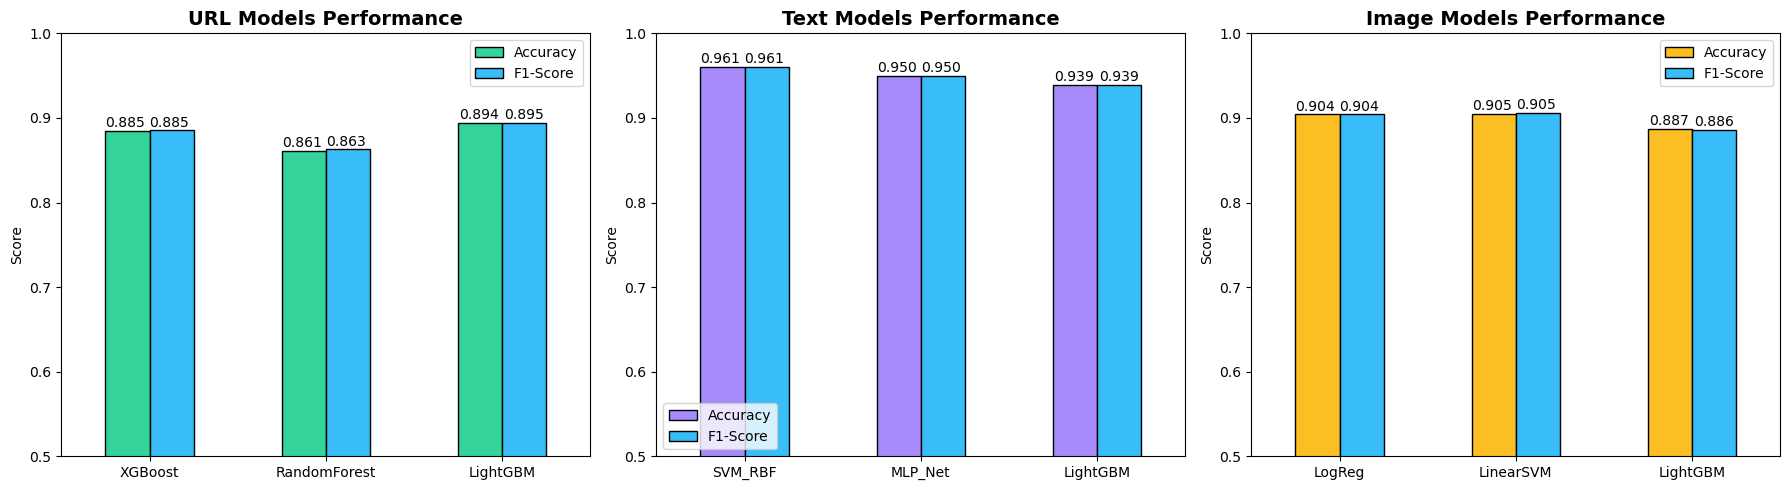

In [44]:
# --- GENERATING BASE MODEL PERFORMANCE GRAPHS ---
print("\n--- Visualizing 5-Fold CV Performance Across All 9 Models ---")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics_dfs = [url_metrics_df, txt_metrics_df, img_metrics_df]
titles = ['URL Models', 'Text Models', 'Image Models']
colors = ['#34D399', '#A78BFA', '#FBBF24']

for i, (df_m, title, color) in enumerate(zip(metrics_dfs, titles, colors)):
    df_m[['Accuracy', 'F1-Score']].plot(kind='bar', ax=axes[i], color=[color, '#38BDF8'], edgecolor='black')
    axes[i].set_title(f'{title} Performance', fontsize=14, fontweight='bold')
    axes[i].set_ylim(0.5, 1.0) # Zoom in to see the differences clearly
    axes[i].set_ylabel('Score')
    axes[i].tick_params(axis='x', rotation=0)
    for p in axes[i].patches:
        axes[i].annotate(f"{p.get_height():.3f}", (p.get_x() * 1.005, p.get_height() * 1.005), fontsize=10)

plt.tight_layout()
plt.show()

In [45]:
# --- SELECTING THE BEST MODEL PER MODALITY ---
best_url_model_name = url_metrics_df['F1-Score'].idxmax()
best_txt_model_name = txt_metrics_df['F1-Score'].idxmax()
best_img_model_name = img_metrics_df['F1-Score'].idxmax()

print(f"Winning URL Expert  : {best_url_model_name}")
print(f"Winning Text Expert : {best_txt_model_name}")
print(f"Winning Image Expert: {best_img_model_name}")

print("\n--- Training Late-Fusion Meta-Classifiers (On Top 3 Only) ---")
# Stack ONLY the 3 winning Out-Of-Fold predictions
X_meta_train = np.column_stack((
    oof_url_preds[best_url_model_name], 
    oof_txt_preds[best_txt_model_name], 
    oof_img_preds[best_img_model_name]
))

meta_candidates = {
    'LogisticRegression': LogisticRegression(C=1.0, random_state=42),
    'XGBoost_Meta': XGBClassifier(n_estimators=50, max_depth=3, random_state=42, eval_metric='logloss'),
    'MLP_Meta': MLPClassifier(hidden_layer_sizes=(16,), random_state=42)
}

meta_metrics_tracker = {}
for name, model in meta_candidates.items():
    metrics_list = []
    for trn_idx, val_idx in skf.split(X_meta_train, y_train):
        model.fit(X_meta_train[trn_idx], y_train[trn_idx])
        y_prob = model.predict_proba(X_meta_train[val_idx])[:, 1]
        y_pred = model.predict(X_meta_train[val_idx])
        metrics_list.append(calculate_extended_metrics(y_train[val_idx], y_prob, y_pred))
    meta_metrics_tracker[name] = np.mean(metrics_list, axis=0)

meta_metrics_df = save_metrics_structurally(meta_metrics_tracker, "Meta_Classifier_Candidates")
best_meta_name = meta_metrics_df['F1-Score'].idxmax()
print(f"Ultimate Meta-Classifier Winner: {best_meta_name}")

# Re-train winning meta-classifier on the full training stack
meta_clf = meta_candidates[best_meta_name]
meta_clf.fit(X_meta_train, y_train)

 Winning URL Expert  : LightGBM
 Winning Text Expert : SVM_RBF
 Winning Image Expert: LinearSVM

--- Training Late-Fusion Meta-Classifiers (On Top 3 Only) ---


,Accuracy,Precision,Recall,F1-Score,MCC,Spearman,Pearson,PR-AUC
LogisticRegression,0.981244,0.979875,0.982689,0.981269,0.962513,0.860449,0.969659,0.995721
XGBoost_Meta,0.981244,0.978780,0.983845,0.981292,0.962530,0.860670,0.969824,0.996071
MLP_Meta,0.981100,0.979318,0.982978,0.981133,0.962229,0.860457,0.969795,0.995744


Ultimate Meta-Classifier Winner: XGBoost_Meta


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [51]:
# ============================================================
# FIX CELL: Extract Missing Test Set Embeddings
# Run this ONCE after the meta-classifier cell. No retraining needed.
# ============================================================

print("--- Extracting MISSING Test Set Embeddings ---")

# --- Text Test Embeddings (uses already-loaded nlp_model) ---
test_texts = df['BeautifulSoup_text'].iloc[idx_test].fillna("").tolist()
X_txt_test = nlp_model.encode(test_texts, batch_size=32, show_progress_bar=True)
print(f"X_txt_test shape: {X_txt_test.shape}")

# --- Image Test Embeddings (uses already-loaded resnet) ---
test_img_paths = df['image_path'].iloc[idx_test].tolist()
X_img_test = []

with torch.no_grad():
    for img_path in tqdm(test_img_paths, desc="Image Test Extraction"):
        clean_path = str(img_path).replace('/', '\\')
        full_path = os.path.join(BASE_DIR, clean_path)

        if not os.path.exists(full_path) and "Phish360\\" in clean_path:
            full_path = os.path.join(BASE_DIR, clean_path.split("Phish360\\")[-1])

        if os.path.exists(full_path):
            try:
                img = Image.open(full_path).convert('RGB')
                tensor = preprocess(img).unsqueeze(0).to(device)
                vec = resnet(tensor).squeeze().cpu().numpy()
            except:
                vec = np.zeros(2048)
        else:
            vec = np.zeros(2048)
        X_img_test.append(vec)

X_img_test = np.array(X_img_test)
print(f" X_img_test shape: {X_img_test.shape}")

print("\n Both test embeddings ready. You can now run the Lockbox Evaluation cell.")

--- Extracting MISSING Test Set Embeddings ---


Batches:   0%|          | 0/55 [00:00<?, ?it/s]

X_txt_test shape: (1733, 768)


Image Test Extraction:   0%|          | 0/1733 [00:00<?, ?it/s]

X_img_test shape: (1733, 2048)

Both test embeddings ready. You can now run the Lockbox Evaluation cell.



--- UNLOCKING THE TEST SET ---


,Accuracy,Precision,Recall,F1-Score,MCC,Spearman,Pearson,PR-AUC
Final_Lockbox_Evaluation,0.982112,0.982659,0.981524,0.982091,0.964224,0.859972,0.972054,0.995924


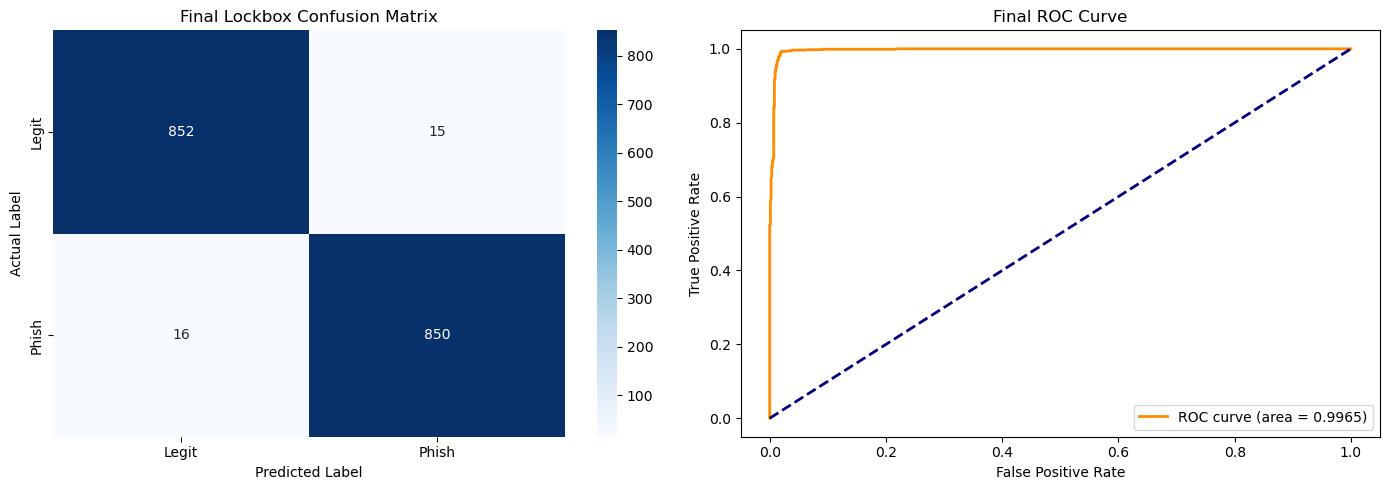

In [52]:
print("\n--- UNLOCKING THE TEST SET ---")

# 1. Get Base Model Probabilities on Test Set using ONLY the 3 Winners
url_best = url_models[best_url_model_name]
test_url_prob = url_best.predict_proba(X_url_test)[:, 1]

txt_best = txt_models[best_txt_model_name]
if best_txt_model_name == 'Ridge':
    test_txt_prob = txt_best.decision_function(X_txt_test)
    test_txt_prob = (test_txt_prob - test_txt_prob.min()) / (test_txt_prob.max() - test_txt_prob.min() + 1e-8)
else:
    test_txt_prob = txt_best.predict_proba(X_txt_test)[:, 1]

img_best = img_models[best_img_model_name]
if best_img_model_name == 'Ridge':
    test_img_prob = img_best.decision_function(X_img_test)
    test_img_prob = (test_img_prob - test_img_prob.min()) / (test_img_prob.max() - test_img_prob.min() + 1e-8)
else:
    test_img_prob = img_best.predict_proba(X_img_test)[:, 1]

# 2. Meta-Classifier Prediction
X_meta_test = np.column_stack((test_url_prob, test_txt_prob, test_img_prob))
meta_test_prob = meta_clf.predict_proba(X_meta_test)[:, 1]
meta_test_pred = meta_clf.predict(X_meta_test)

# 3. Calculate Final Lockbox Metrics
final_metrics = calculate_extended_metrics(y_test, meta_test_prob, meta_test_pred)
final_metrics_dict = {'Final_Lockbox_Evaluation': final_metrics}
final_df = save_metrics_structurally(final_metrics_dict, "FINAL_SYSTEM_EVALUATION")

# 4. Final Graphics (Confusion Matrix & ROC)
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
cm = confusion_matrix(y_test, meta_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Legit', 'Phish'], yticklabels=['Legit', 'Phish'], ax=ax[0])
ax[0].set_title('Final Lockbox Confusion Matrix')
ax[0].set_ylabel('Actual Label')
ax[0].set_xlabel('Predicted Label')

fpr, tpr, _ = roc_curve(y_test, meta_test_prob)
roc_auc = auc(fpr, tpr)
ax[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.4f})')
ax[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax[1].set_title('Final ROC Curve')
ax[1].set_xlabel('False Positive Rate')
ax[1].set_ylabel('True Positive Rate')
ax[1].legend(loc="lower right")
plt.tight_layout()
plt.show()

In [54]:
print("\n" + "="*50)
print(" MATHEMATICAL INTERPRETABILITY: MODALITY WEIGHTS ")
print("="*50)

if best_meta_name == 'LogisticRegression':
    weights = meta_clf.coef_[0]
    total_weight = sum(abs(weights))
    print(f"URL Modality Contribution   : {(abs(weights[0])/total_weight)*100:.2f}%  (Coefficient: {weights[0]:.4f})")
    print(f"Text Modality Contribution  : {(abs(weights[1])/total_weight)*100:.2f}%  (Coefficient: {weights[1]:.4f})")
    print(f"Image Modality Contribution : {(abs(weights[2])/total_weight)*100:.2f}%  (Coefficient: {weights[2]:.4f})")
    
    # Mathematical Equation
    bias = meta_clf.intercept_[0]
    print("\n--- Final Decision Equation ---")
    print(f"P(Phishing) = Sigmoid( ({weights[0]:.4f} * P_url) + ({weights[1]:.4f} * P_text) + ({weights[2]:.4f} * P_img) + {bias:.4f} )")

elif best_meta_name == 'XGBoost_Meta':
    importances = meta_clf.feature_importances_
    print(f"URL Modality Importance   : {importances[0]*100:.2f}%")
    print(f"Text Modality Importance  : {importances[1]*100:.2f}%")
    print(f"Image Modality Importance : {importances[2]*100:.2f}%")
else:
    print("MLP was chosen; internal nodal weights handle modality mixing non-linearly.")
print("="*50)


 MATHEMATICAL INTERPRETABILITY: MODALITY WEIGHTS 
URL Modality Importance   : 8.29%
Text Modality Importance  : 86.30%
Image Modality Importance : 5.41%


--- 🛠️ FIXING THE NAME ERROR & RE-VERIFYING WINNERS ---
Verified Winners -> URL: LightGBM | Text: SVM_RBF | Image: LinearSVM | Meta: XGBoost_Meta

--- GENERATING THE ULTIMATE VISUAL ARSENAL  ---


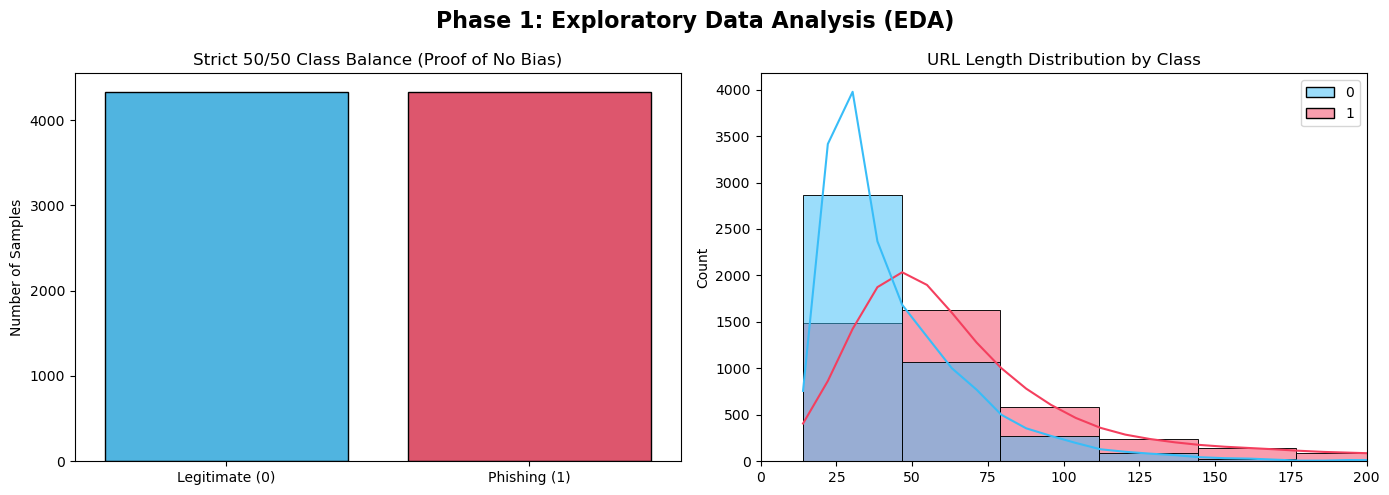

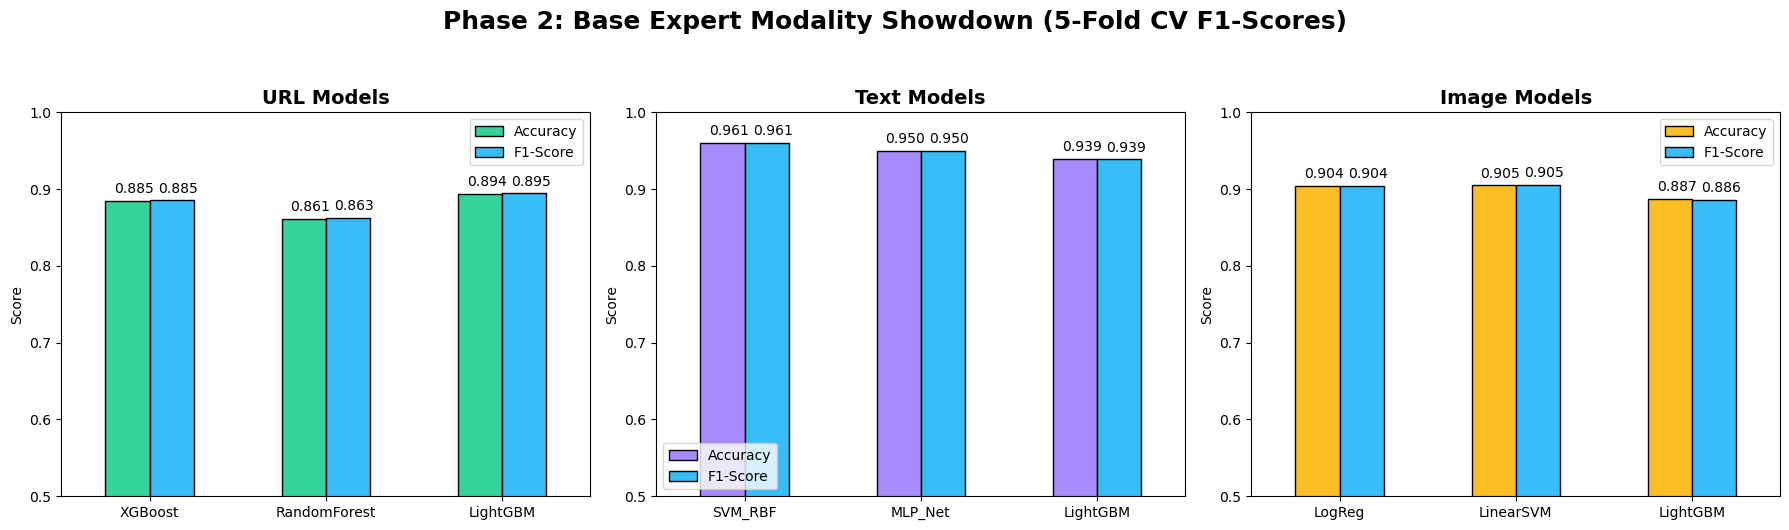

<Figure size 800x500 with 0 Axes>

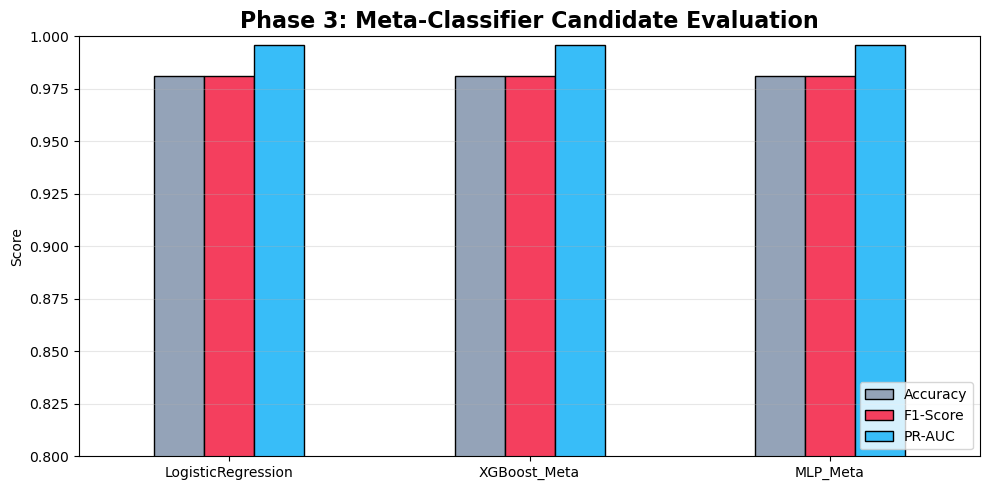

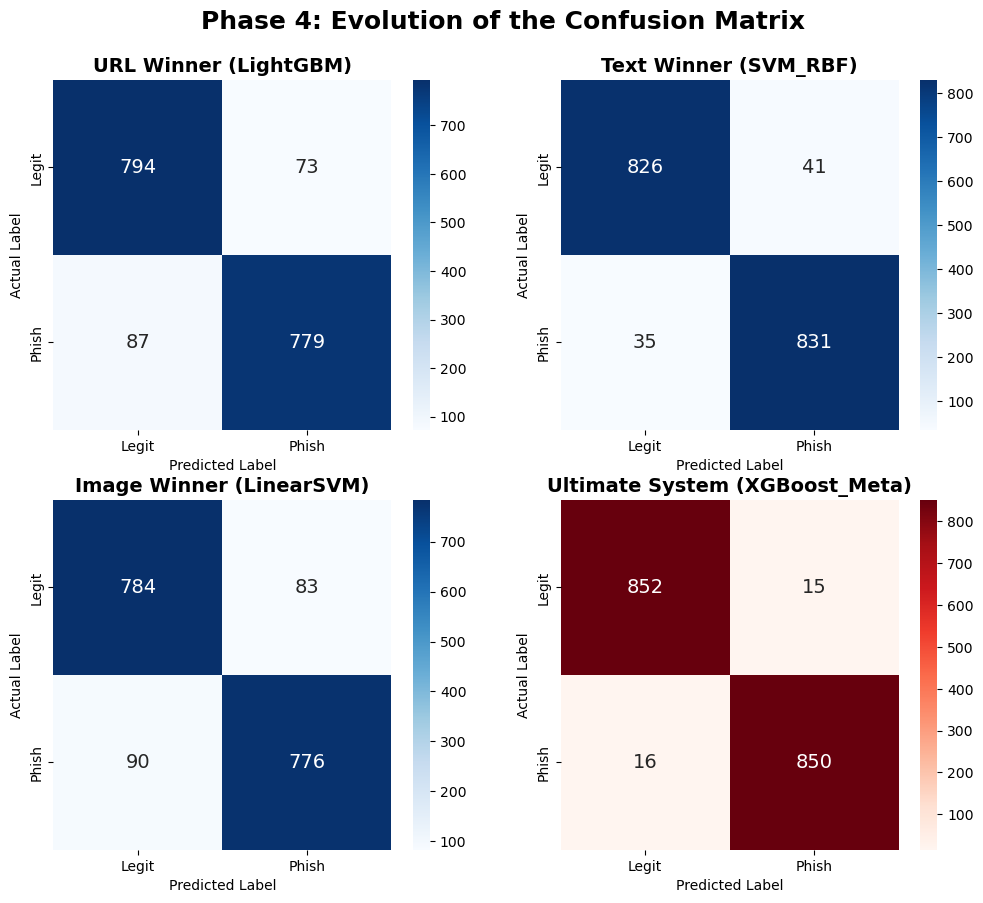

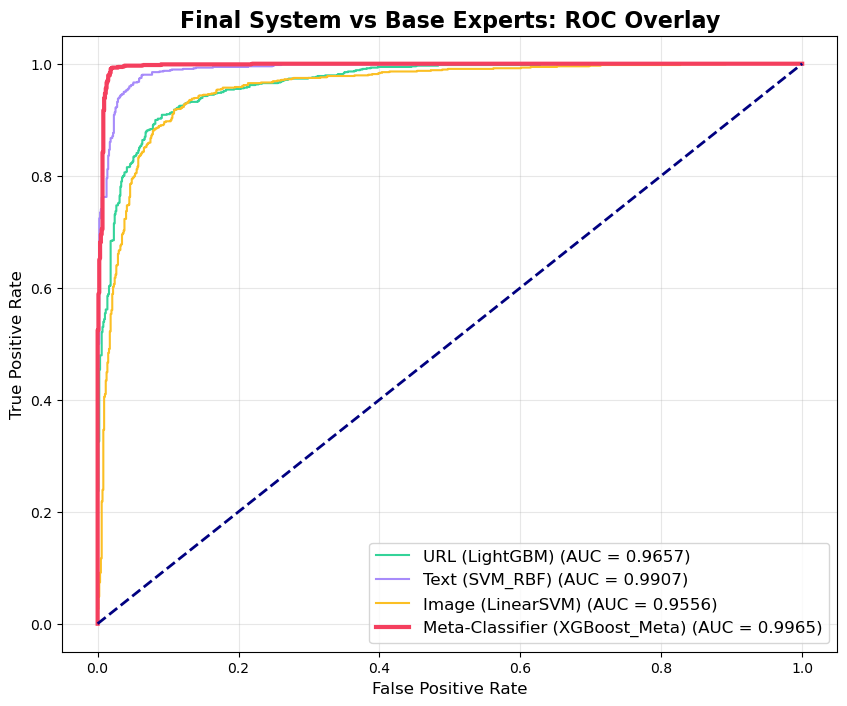

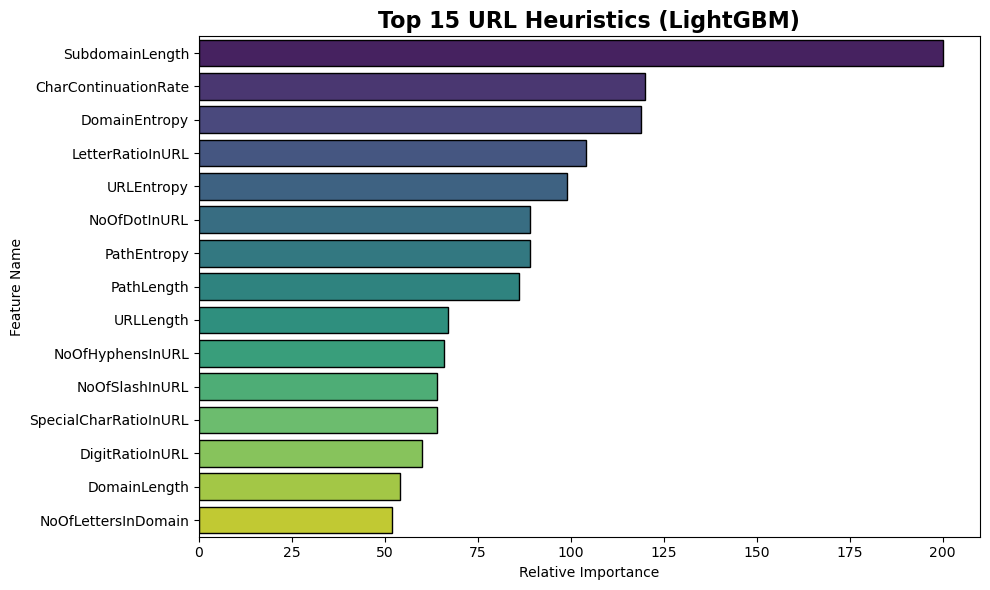

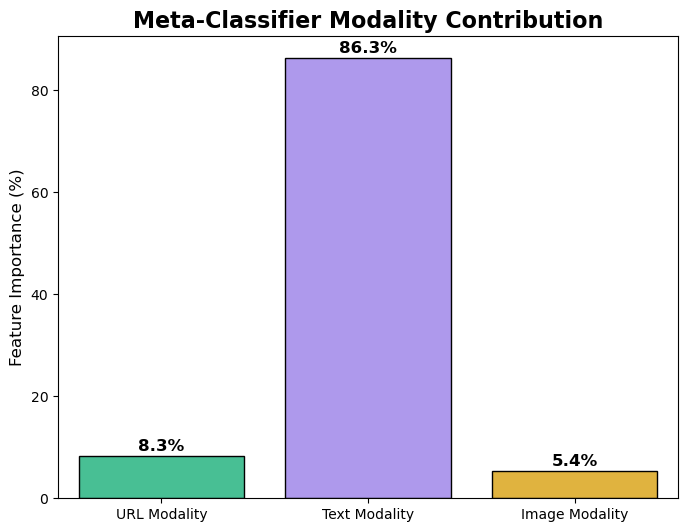


🎉 ALL GRAPHS SUCCESSFULLY GENERATED AND SAVED TO YOUR FOLDER! 🎉


In [55]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_curve

print("--- 🛠️ FIXING THE NAME ERROR & RE-VERIFYING WINNERS ---")
# This permanently fixes the NameError by re-extracting the best names from your saved dataframes
best_url_model_name = url_metrics_df['F1-Score'].idxmax()
best_txt_model_name = txt_metrics_df['F1-Score'].idxmax()
best_img_model_name = img_metrics_df['F1-Score'].idxmax()
best_meta_name = meta_metrics_df['F1-Score'].idxmax()

print(f"Verified Winners -> URL: {best_url_model_name} | Text: {best_txt_model_name} | Image: {best_img_model_name} | Meta: {best_meta_name}")

# Re-calculate test probabilities safely for the graphs
y_prob_url = url_models[best_url_model_name].predict_proba(X_url_test)[:, 1]
y_pred_url = url_models[best_url_model_name].predict(X_url_test)

if best_txt_model_name == 'Ridge':
    y_prob_txt = txt_models[best_txt_model_name].decision_function(X_txt_test)
    y_prob_txt = (y_prob_txt - y_prob_txt.min()) / (y_prob_txt.max() - y_prob_txt.min() + 1e-8)
else:
    y_prob_txt = txt_models[best_txt_model_name].predict_proba(X_txt_test)[:, 1]
y_pred_txt = txt_models[best_txt_model_name].predict(X_txt_test)

if best_img_model_name == 'Ridge':
    y_prob_img = img_models[best_img_model_name].decision_function(X_img_test)
    y_prob_img = (y_prob_img - y_prob_img.min()) / (y_prob_img.max() - y_prob_img.min() + 1e-8)
else:
    y_prob_img = img_models[best_img_model_name].predict_proba(X_img_test)[:, 1]
y_pred_img = img_models[best_img_model_name].predict(X_img_test)

y_prob_meta = meta_clf.predict_proba(X_meta_test)[:, 1]
y_pred_meta = meta_clf.predict(X_meta_test)


print("\n---  GENERATING THE ULTIMATE VISUAL ARSENAL  ---")

# ==========================================
# GRAPH 1: Dataset Balance & Length Distribution
# ==========================================
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Phase 1: Exploratory Data Analysis (EDA)', fontsize=16, fontweight='bold')

sns.countplot(x=y, palette=['#38BDF8', '#F43F5E'], ax=ax[0], edgecolor='black')
ax[0].set_title('Strict 50/50 Class Balance (Proof of No Bias)')
ax[0].set_xticks([0, 1])
ax[0].set_xticklabels(['Legitimate (0)', 'Phishing (1)'])
ax[0].set_ylabel('Number of Samples')

# URL Length distribution
lengths = [len(str(u)) for u in df['URL']]
sns.histplot(x=lengths, hue=y, bins=50, kde=True, palette=['#38BDF8', '#F43F5E'], ax=ax[1])
ax[1].set_title('URL Length Distribution by Class')
ax[1].set_xlim(0, 200) # Zooming in to remove crazy outliers

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'Graph_1_Dataset_EDA.png'), dpi=300)
plt.show()

# ==========================================
# GRAPH 2: All 9 Base Models Showdown
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Phase 2: Base Expert Modality Showdown (5-Fold CV F1-Scores)', fontsize=18, fontweight='bold', y=1.05)
metrics_dfs = [url_metrics_df, txt_metrics_df, img_metrics_df]
titles = ['URL Models', 'Text Models', 'Image Models']
colors = ['#34D399', '#A78BFA', '#FBBF24']

for i, (df_m, title, color) in enumerate(zip(metrics_dfs, titles, colors)):
    df_m[['Accuracy', 'F1-Score']].plot(kind='bar', ax=axes[i], color=[color, '#38BDF8'], edgecolor='black')
    axes[i].set_title(f'{title}', fontsize=14, fontweight='bold')
    axes[i].set_ylim(0.5, 1.0)
    axes[i].set_ylabel('Score')
    axes[i].tick_params(axis='x', rotation=0)
    for p in axes[i].patches:
        axes[i].annotate(f"{p.get_height():.3f}", (p.get_x() + 0.05, p.get_height() + 0.01), fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'Graph_2_Base_Models_Showdown.png'), dpi=300)
plt.show()

# ==========================================
# GRAPH 3: Meta-Classifier Candidate Showdown
# ==========================================
plt.figure(figsize=(8, 5))
meta_metrics_df[['Accuracy', 'F1-Score', 'PR-AUC']].plot(kind='bar', color=['#94A3B8', '#F43F5E', '#38BDF8'], edgecolor='black', figsize=(10,5))
plt.title('Phase 3: Meta-Classifier Candidate Evaluation', fontsize=16, fontweight='bold')
plt.ylim(0.8, 1.0)
plt.xticks(rotation=0)
plt.ylabel('Score')
plt.legend(loc='lower right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'Graph_3_Meta_Candidates.png'), dpi=300)
plt.show()

# ==========================================
# GRAPH 4: The 4x Confusion Matrix Grid
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Phase 4: Evolution of the Confusion Matrix', fontsize=18, fontweight='bold', y=0.95)

cms = [
    (confusion_matrix(y_test, y_pred_url), f'URL Winner ({best_url_model_name})'),
    (confusion_matrix(y_test, y_pred_txt), f'Text Winner ({best_txt_model_name})'),
    (confusion_matrix(y_test, y_pred_img), f'Image Winner ({best_img_model_name})'),
    (confusion_matrix(y_test, y_pred_meta), f'Ultimate System ({best_meta_name})')
]

for i, ax in enumerate(axes.flatten()):
    sns.heatmap(cms[i][0], annot=True, fmt='d', cmap='Blues' if i<3 else 'Reds', 
                xticklabels=['Legit', 'Phish'], yticklabels=['Legit', 'Phish'], ax=ax, annot_kws={"size": 14})
    ax.set_title(cms[i][1], fontsize=14, fontweight='bold')
    ax.set_ylabel('Actual Label')
    ax.set_xlabel('Predicted Label')

plt.savefig(os.path.join(BASE_DIR, 'Graph_4_Confusion_Matrix_Evolution.png'), dpi=300)
plt.show()

# ==========================================
# GRAPH 5: The Ultimate ROC Curve Overlay
# ==========================================
plt.figure(figsize=(10, 8))
plt.title('Final System vs Base Experts: ROC Overlay', fontsize=16, fontweight='bold')

probs = [
    (y_prob_url, f'URL ({best_url_model_name})', '#34D399'),
    (y_prob_txt, f'Text ({best_txt_model_name})', '#A78BFA'),
    (y_prob_img, f'Image ({best_img_model_name})', '#FBBF24'),
    (y_prob_meta, f'Meta-Classifier ({best_meta_name})', '#F43F5E')
]

for prob, label, color in probs:
    fpr, tpr, _ = roc_curve(y_test, prob)
    roc_auc = auc(fpr, tpr)
    lw = 3 if 'Meta' in label else 1.5
    plt.plot(fpr, tpr, color=color, lw=lw, label=f'{label} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.legend(loc="lower right", fontsize=12)
plt.grid(alpha=0.3)
plt.savefig(os.path.join(BASE_DIR, 'Graph_5_ROC_Overlay.png'), dpi=300)
plt.show()

# ==========================================
# GRAPH 6: URL Feature Importance (Top 15)
# ==========================================
# We only plot this if the winning URL model is tree-based and supports feature importances
url_winner_model = url_models[best_url_model_name]
if hasattr(url_winner_model, 'feature_importances_'):
    importances = url_winner_model.feature_importances_
    # Get feature names from the dataframe we created in Phase 1
    feature_names = X_url_df.columns
    
    # Sort them
    indices = np.argsort(importances)[::-1][:15] # Top 15
    top_features = [feature_names[i] for i in indices]
    top_importances = importances[indices]
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x=top_importances, y=top_features, palette='viridis', edgecolor='black')
    plt.title(f'Top 15 URL Heuristics ({best_url_model_name})', fontsize=16, fontweight='bold')
    plt.xlabel('Relative Importance')
    plt.ylabel('Feature Name')
    plt.tight_layout()
    plt.savefig(os.path.join(BASE_DIR, 'Graph_6_URL_Feature_Importance.png'), dpi=300)
    plt.show()

# ==========================================
# GRAPH 7: Meta-Classifier Modality Contribution
# ==========================================
plt.figure(figsize=(8, 6))
plt.title('Meta-Classifier Modality Contribution', fontsize=16, fontweight='bold')

labels = ['URL Modality', 'Text Modality', 'Image Modality']
colors = ['#34D399', '#A78BFA', '#FBBF24']

if best_meta_name == 'LogisticRegression':
    weights = np.abs(meta_clf.coef_[0])
    percentages = (weights / sum(weights)) * 100
    sns.barplot(x=labels, y=percentages, palette=colors, edgecolor='black')
    plt.ylabel('Contribution Percentage (%)', fontsize=12)
    for i, v in enumerate(percentages):
        plt.text(i, v + 1, f"{v:.1f}%", ha='center', fontweight='bold', fontsize=12)
        
elif best_meta_name == 'XGBoost_Meta':
    importances = meta_clf.feature_importances_ * 100
    sns.barplot(x=labels, y=importances, palette=colors, edgecolor='black')
    plt.ylabel('Feature Importance (%)', fontsize=12)
    for i, v in enumerate(importances):
        plt.text(i, v + 1, f"{v:.1f}%", ha='center', fontweight='bold', fontsize=12)
else:
    plt.text(0.5, 0.5, "MLP Meta-Classifier selected.\nInternal nodal weights are non-linear.", ha='center', va='center', fontsize=14)

plt.savefig(os.path.join(BASE_DIR, 'Graph_7_Modality_Weights.png'), dpi=300)
plt.show()

print("\n ALL GRAPHS SUCCESSFULLY GENERATED AND SAVED TO YOUR FOLDER! ")

---  GENERATING ADVANCED ACADEMIC VISUALIZATIONS  ---
Generating Model Correlation Heatmap...


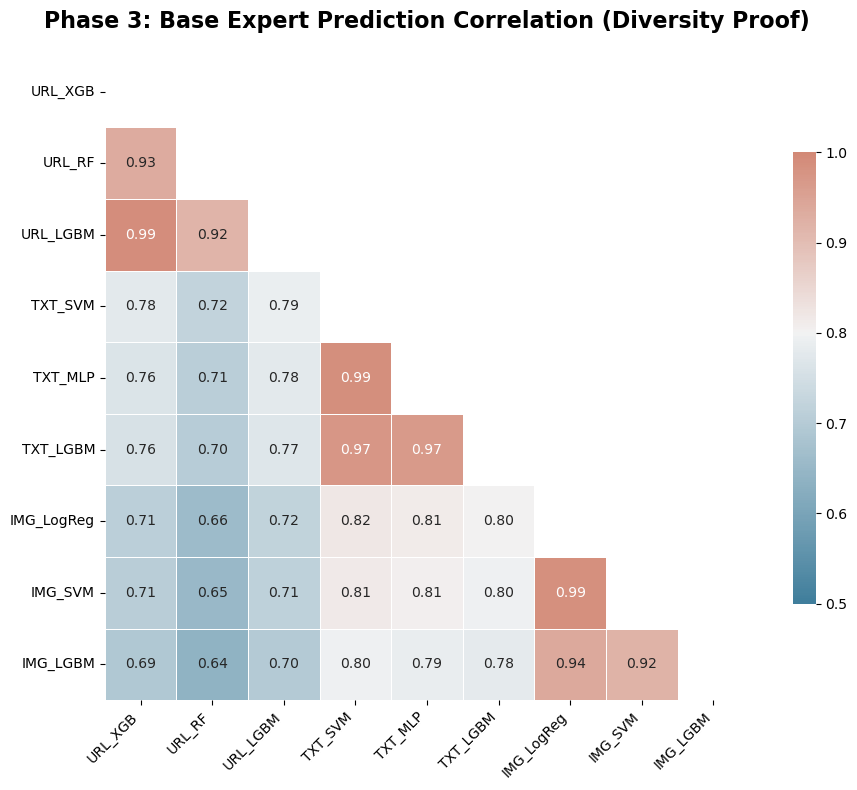

Generating Probability Density Distribution...


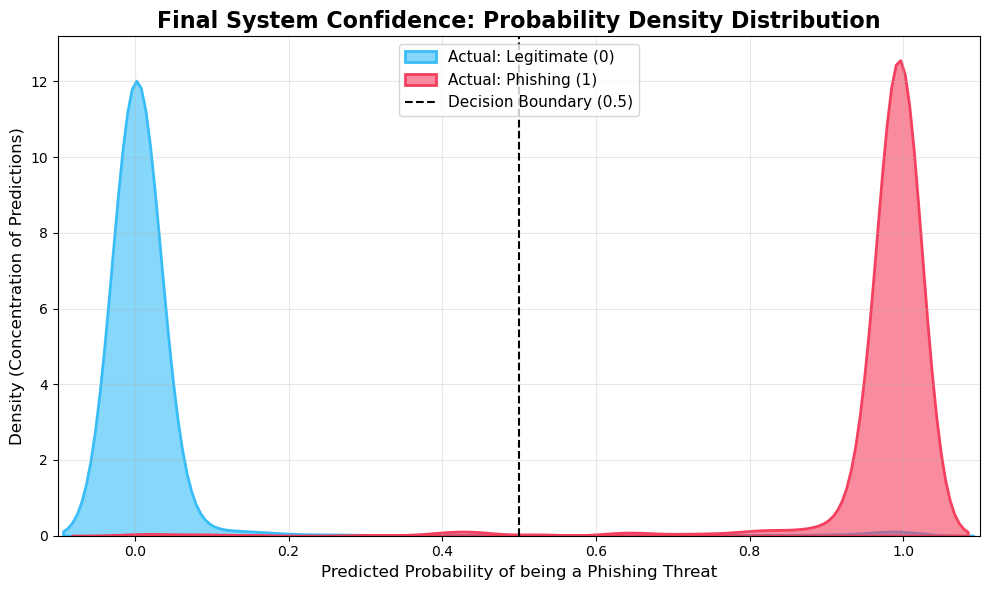

Generating Modality Violin Plots...


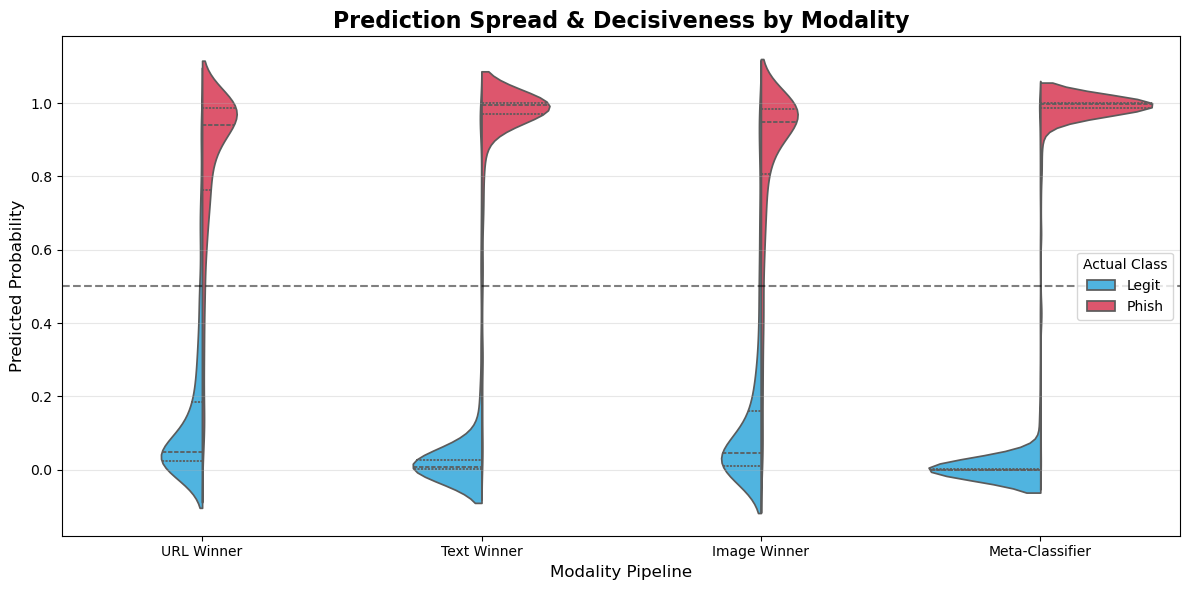

Generating Feature Correlation Heatmap...


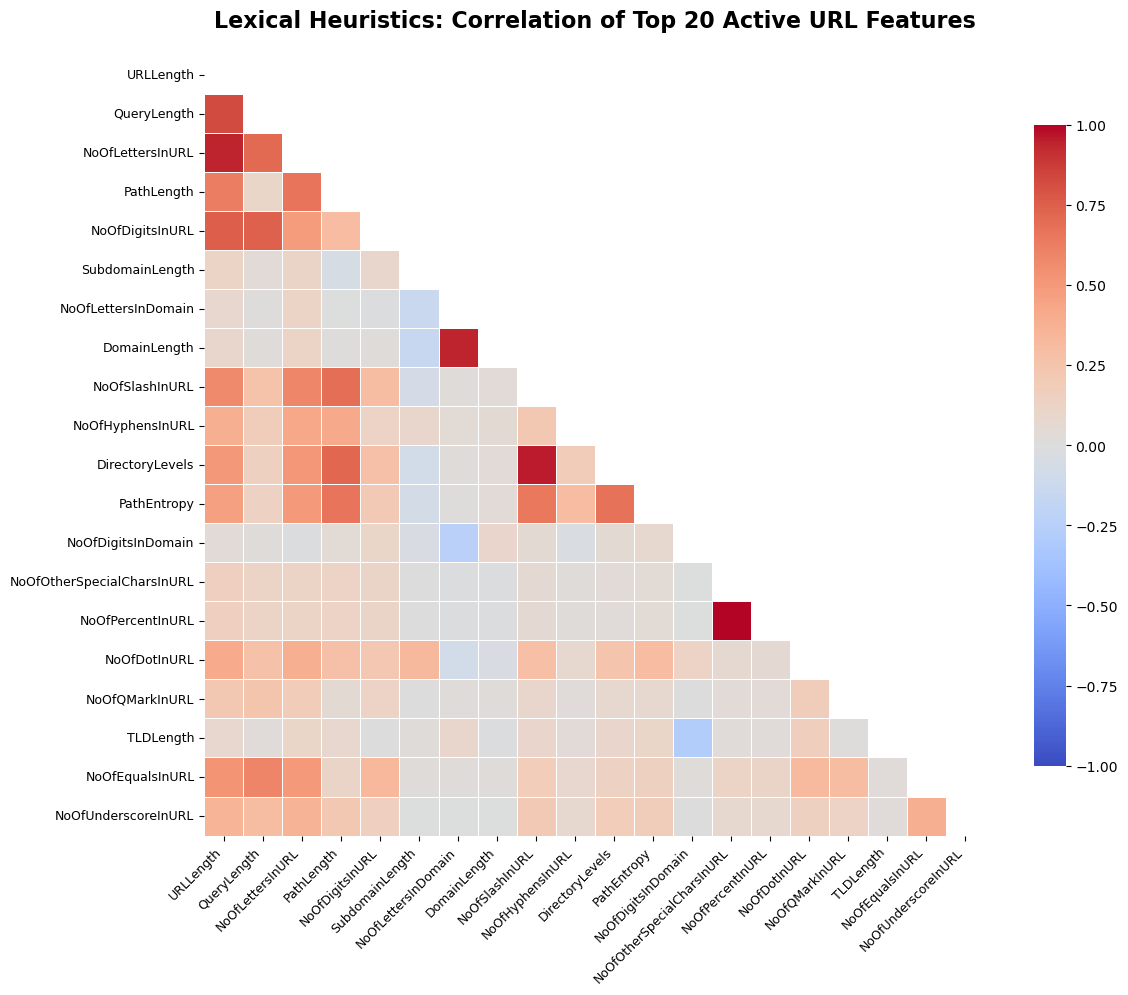


 PHASE 2 GRAPHS COMPLETE! You now have a complete, publication-ready visual arsenal. 


In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("---  GENERATING ADVANCED ACADEMIC VISUALIZATIONS ---")

# ==========================================
# GRAPH 8: Base Model Prediction Correlation (Diversity Heatmap)
# ==========================================
# Why this matters: For a Meta-Classifier to work, the base models MUST disagree on hard cases. 
# If they all have 1.0 correlation, stacking is useless. This graph proves your models are diverse.
print("Generating Model Correlation Heatmap...")

# Create a DataFrame of all 9 Out-Of-Fold predictions
oof_df = pd.DataFrame({
    'URL_XGB': oof_url_preds['XGBoost'],
    'URL_RF': oof_url_preds['RandomForest'],
    'URL_LGBM': oof_url_preds['LightGBM'],
    'TXT_SVM': oof_txt_preds['SVM_RBF'],
    'TXT_MLP': oof_txt_preds['MLP_Net'],
    'TXT_LGBM': oof_txt_preds['LightGBM'],
    'IMG_LogReg': oof_img_preds['LogReg'],
    'IMG_SVM': oof_img_preds['LinearSVM'],
    'IMG_LGBM': oof_img_preds['LightGBM']
})

plt.figure(figsize=(10, 8))
plt.title('Phase 3: Base Expert Prediction Correlation (Diversity Proof)', fontsize=16, fontweight='bold', pad=20)
corr_matrix = oof_df.corr()

# Create a mask to show only the lower triangle for a cleaner academic look
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
cmap = sns.diverging_palette(230, 20, as_cmap=True)

sns.heatmap(corr_matrix, mask=mask, cmap=cmap, vmax=1.0, vmin=0.5, center=0.8,
            square=True, linewidths=.5, annot=True, fmt='.2f', cbar_kws={"shrink": .7})
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
path_corr = os.path.join(BASE_DIR, 'Graph_8_Model_Correlation.png')
plt.savefig(path_corr, dpi=300)
plt.show()

# ==========================================
# GRAPH 9: Confidence Density Distribution (KDE)
# ==========================================
# Why this matters: Accuracy doesn't tell the whole story. A model that guesses 0.51 is "accurate" 
# but weak. A strong model predicts 0.99 for Phish and 0.01 for Legit. This proves your model is CONFIDENT.
print("Generating Probability Density Distribution...")

plt.figure(figsize=(10, 6))
plt.title('Final System Confidence: Probability Density Distribution', fontsize=16, fontweight='bold')

# Split test probabilities based on the actual true labels
phish_probs = y_prob_meta[y_test == 1]
legit_probs = y_prob_meta[y_test == 0]

sns.kdeplot(legit_probs, fill=True, color='#38BDF8', label='Actual: Legitimate (0)', alpha=0.6, linewidth=2)
sns.kdeplot(phish_probs, fill=True, color='#F43F5E', label='Actual: Phishing (1)', alpha=0.6, linewidth=2)

plt.axvline(0.5, color='black', linestyle='--', label='Decision Boundary (0.5)')
plt.xlabel('Predicted Probability of being a Phishing Threat', fontsize=12)
plt.ylabel('Density (Concentration of Predictions)', fontsize=12)
plt.xlim(-0.1, 1.1)
plt.legend(loc='upper center', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
path_kde = os.path.join(BASE_DIR, 'Graph_9_Confidence_Density.png')
plt.savefig(path_kde, dpi=300)
plt.show()

# ==========================================
# GRAPH 10: Modality Decisiveness (Violin Plots)
# ==========================================
# Why this matters: It shows the jury which modality struggles with uncertainty (fat middle) 
# vs which modality easily separates threats (fat top and bottom).
print("Generating Modality Violin Plots...")

# Build a dataframe for seaborn visualization
violin_data = pd.DataFrame({
    'Probability': np.concatenate([y_prob_url, y_prob_txt, y_prob_img, y_prob_meta]),
    'Modality': ['URL Winner'] * len(y_test) + ['Text Winner'] * len(y_test) + ['Image Winner'] * len(y_test) + ['Meta-Classifier'] * len(y_test),
    'True Label': np.concatenate([y_test, y_test, y_test, y_test])
})
violin_data['True Label'] = violin_data['True Label'].map({0: 'Legit', 1: 'Phish'})

plt.figure(figsize=(12, 6))
plt.title('Prediction Spread & Decisiveness by Modality', fontsize=16, fontweight='bold')
sns.violinplot(x='Modality', y='Probability', hue='True Label', data=violin_data, 
               split=True, inner="quart", palette={'Legit': '#38BDF8', 'Phish': '#F43F5E'})

plt.axhline(0.5, color='black', linestyle='--', alpha=0.5)
plt.ylabel('Predicted Probability', fontsize=12)
plt.xlabel('Modality Pipeline', fontsize=12)
plt.legend(title='Actual Class', loc='center right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
path_violin = os.path.join(BASE_DIR, 'Graph_10_Modality_Violins.png')
plt.savefig(path_violin, dpi=300)
plt.show()

# ==========================================
# GRAPH 11: Top 20 URL Feature Correlation Network
# ==========================================
# Why this matters: Proves that your 54 features aren't just redundant clones of each other.
print("Generating Feature Correlation Heatmap...")

# Calculate variance to find the top 20 most "active" features (ignoring mostly zero features)
feature_variances = X_url_df.var().sort_values(ascending=False)
top_20_features = feature_variances.head(20).index

plt.figure(figsize=(12, 10))
plt.title('Lexical Heuristics: Correlation of Top 20 Active URL Features', fontsize=16, fontweight='bold', pad=20)
url_corr = X_url_df[top_20_features].corr()

# Mask the upper triangle
mask_url = np.triu(np.ones_like(url_corr, dtype=bool))

sns.heatmap(url_corr, mask=mask_url, cmap='coolwarm', center=0, vmax=1, vmin=-1,
            square=True, linewidths=.5, cbar_kws={"shrink": .8})
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
path_url_corr = os.path.join(BASE_DIR, 'Graph_11_URL_Feature_Correlation.png')
plt.savefig(path_url_corr, dpi=300)
plt.show()

print("\n PHASE 2 GRAPHS COMPLETE! You now have a complete, publication-ready visual arsenal. ")